# Seed-Conformation Pilot: Does AlphaFold's Own Structural Uncertainty Predict Model Error?

A 10-protein pilot (5 best-, 5 worst-predicted by the two full-dataset champions,
ranked by mean Pearson r on the real test split) x 5 AlphaFold conformations each,
generated locally via ColabFold (`--num-seeds 5`, fixed `--random-seed 0`, one AF2
model). All 50 synthetic structures were run through the **existing, unmodified**
data-generation pipeline (PDB2PQR -> APBS -> mesh -> ESP sampling) and then
frozen-backbone inference with both full-dataset champions.

**Central question**: if AlphaFold itself can't agree on a single structure across
random seeds for a given sequence, is that protein's ESP also hard for the GNN to
predict -- i.e. is at least some of the model's difficulty actually a structural
target-uncertainty problem inherited from AlphaFold, not a shortcoming of the ESP
model itself?

**A real, hard-won environment limitation**: this local ColabFold install
(jax/jaxlib 0.10.1, A100, CUDA 13 driver) reliably fails -- either exact-NaN or
exact-all-zero output from the very first forward pass -- for sequences
>~550-560 residues, regardless of seven distinct mitigations tried (disabling
unified memory, `--compile-mode fast`, forcing float32 matmul precision,
`use_bfloat16=False`, 4x-reduced MSA depth, and even reinstalling jax at a much
older pinned version, 0.5.3, with an identical result). This isn't a version bug --
it looks like a genuine GPU/XLA-compilation limit for large shapes on this specific
environment. The pilot's "worst" group is therefore capped at <=550 residues,
selected as the worst-ranked proteins meeting that constraint (not the global
worst-ranked, which trend considerably larger) -- see `scripts/run_seed_conformations.py`'s
module docstring for the full diagnostic trail, and
`/home/student/thesis/outputs/seed_pilot_failures.csv` for exactly which candidates were tried and
rejected.

**Pipeline** (each stage independently verified, cached, and reusable):
1. `scripts/run_seed_conformations.py` -- ColabFold generation + placement +
   data-gen, with automatic candidate replacement on failure (NaN or
   empty-structure detection, both verified against real cases).
2. `scripts/eval_seed_conformations.py` -- graph build + frozen-backbone
   inference with both champions, written to a separate directory so the real
   848-protein test-split predictions are never touched.
3. `scripts/compute_seed_agreement.py` -- Kabsch-aligned inter-seed CA-RMSD +
   cross-seed RBF-interpolated ESP-field Pearson r/RMSE (each non-reference
   seed's field is re-fit as an RBF interpolator in the aligned frame and
   evaluated at the reference seed's own vertices -- the only way to compare
   ESP fields defined on structurally different meshes).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu

sys.path.insert(0, str(Path("..").resolve()))

GROUP_COLORS = {"best": "steelblue", "worst": "firebrick"}
MODEL_COLORS = {"attention": "steelblue", "distance": "darkorange"}

---
## 1. Load Cached Outputs

In [2]:
manifest  = pd.read_csv("/home/student/thesis/outputs/seed_conformation_manifest.csv")
pilot     = pd.read_csv("/home/student/thesis/outputs/seed_pilot_proteins.csv")
failures  = pd.read_csv("/home/student/thesis/outputs/seed_pilot_failures.csv")
eval_summary = pd.read_csv("/home/student/thesis/outputs/seed_conformation_eval_summary.csv")
agreement = pd.read_csv("/home/student/thesis/outputs/seed_conformation_agreement.csv")

print(f"Pilot: {len(pilot)} parent proteins ({(pilot.pilot_group=='best').sum()} best, "
      f"{(pilot.pilot_group=='worst').sum()} worst) x 5 seeds = {len(manifest)} synthetic structures")
print(f"Data-gen success: {(manifest.data_gen_status=='complete').sum()}/{len(manifest)}")
print(f"Candidates tried and rejected before securing the final 10: {len(failures)}")
display(failures)

Pilot: 10 parent proteins (5 best, 5 worst) x 5 seeds = 50 synthetic structures
Data-gen success: 50/50
Candidates tried and rejected before securing the final 10: 3


,protein_id,pilot_group,candidate_rank,reason,error
0,AF-Q8CV11-F1,best,1,nan_predictions,NaN predictions for AF-Q8CV11-F1
1,AF-Q8FJB6-F1,worst,0,nan_predictions,NaN predictions for AF-Q8FJB6-F1
2,AF-P51030-F1,worst,3,nan_predictions,NaN predictions for AF-P51030-F1


---
## 2. Inter-Seed Structural & ESP-Field Agreement

For each protein, every non-reference seed is rigid-body aligned onto seed 0 via
Kabsch (CA atoms), giving a structural CA-RMSD. That same transform brings the
seed's whole ESP field into the reference frame, where it's re-interpolated and
compared directly against the reference's own field.

In [3]:
display_cols = ["parent_protein_id", "pilot_group", "mean_ca_rmsd", "max_ca_rmsd",
                "mean_esp_field_r", "min_esp_field_r", "mean_esp_field_rmse"]
pd.set_option("display.float_format", "{:.3f}".format)
display(agreement[display_cols].sort_values("mean_ca_rmsd"))

print("\nGroup means:")
display(agreement.groupby("pilot_group")[["mean_ca_rmsd", "mean_esp_field_r"]].mean())

,parent_protein_id,pilot_group,mean_ca_rmsd,max_ca_rmsd,mean_esp_field_r,min_esp_field_r,mean_esp_field_rmse
1,AF-C3PNP6-F1,best,0.087,0.119,0.986,0.981,0.841
6,AF-Q64XA6-F1,best,0.099,0.136,0.971,0.908,1.453
4,AF-P11245-F1,worst,0.108,0.218,0.923,0.874,1.145
2,AF-O28389-F1,best,0.225,0.382,0.976,0.973,0.765
5,AF-Q4G0W2-F1,best,1.158,1.244,0.981,0.976,0.913
8,AF-Q6IGX9-F1,best,3.496,4.950,0.734,0.587,1.728
0,AF-A2T2X4-F1,worst,16.290,17.805,0.568,0.518,2.628
3,AF-O62732-F1,worst,21.720,27.128,0.435,0.319,2.613
9,AF-Q9SF32-F1,worst,23.848,31.053,0.488,0.335,2.873
7,AF-Q6DGN6-2-F1,worst,49.962,60.003,0.181,-0.058,3.593



Group means:


,mean_ca_rmsd,mean_esp_field_r
pilot_group,,
best,1.013,0.930
worst,22.386,0.519


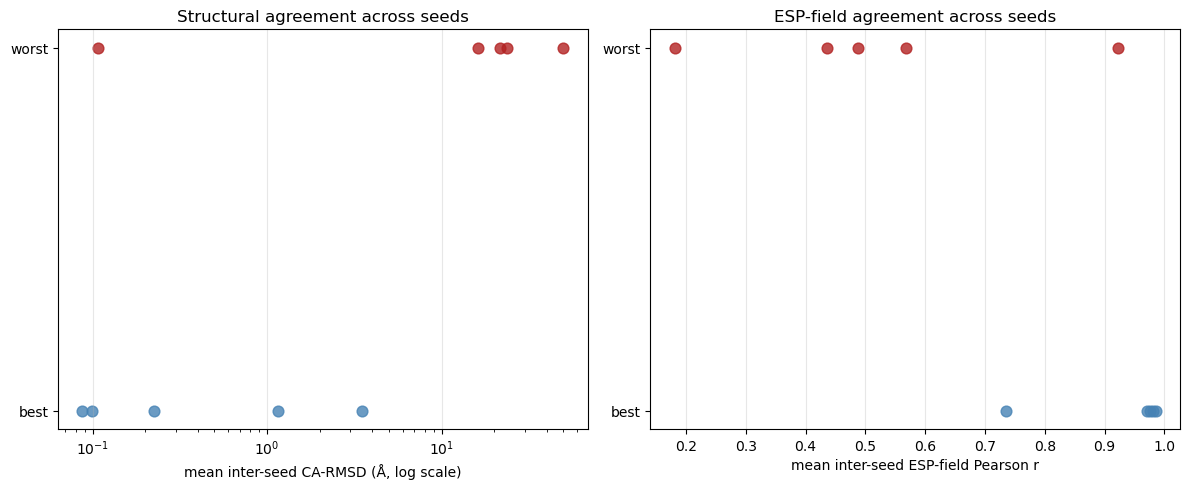

Mann-Whitney U, best vs worst CA-RMSD:      p=0.0556
Mann-Whitney U, best vs worst ESP-field r:   p=0.0159


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for group, color in GROUP_COLORS.items():
    sub = agreement[agreement.pilot_group == group]
    axes[0].scatter(sub["mean_ca_rmsd"], [group] * len(sub), color=color, s=60, alpha=0.8, label=group)
    axes[1].scatter(sub["mean_esp_field_r"], [group] * len(sub), color=color, s=60, alpha=0.8, label=group)
axes[0].set_xlabel("mean inter-seed CA-RMSD (\u00c5, log scale)")
axes[0].set_xscale("log")
axes[0].set_title("Structural agreement across seeds")
axes[0].grid(axis="x", alpha=0.3)
axes[1].set_xlabel("mean inter-seed ESP-field Pearson r")
axes[1].set_title("ESP-field agreement across seeds")
axes[1].grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

u_ca = mannwhitneyu(agreement[agreement.pilot_group=="best"].mean_ca_rmsd,
                     agreement[agreement.pilot_group=="worst"].mean_ca_rmsd)
u_field = mannwhitneyu(agreement[agreement.pilot_group=="best"].mean_esp_field_r,
                        agreement[agreement.pilot_group=="worst"].mean_esp_field_r)
print(f"Mann-Whitney U, best vs worst CA-RMSD:      p={u_ca.pvalue:.4f}")
print(f"Mann-Whitney U, best vs worst ESP-field r:   p={u_field.pvalue:.4f}")

---
## 3. Does Inter-Seed Disagreement Predict Model Error?

Each protein's mean model RMSE across its own 5 seeds (from
`scripts/eval_seed_conformations.py`), correlated against that same protein's
inter-seed structural/ESP-field agreement -- pooling across both pilot groups
(n=10), not just comparing group averages.

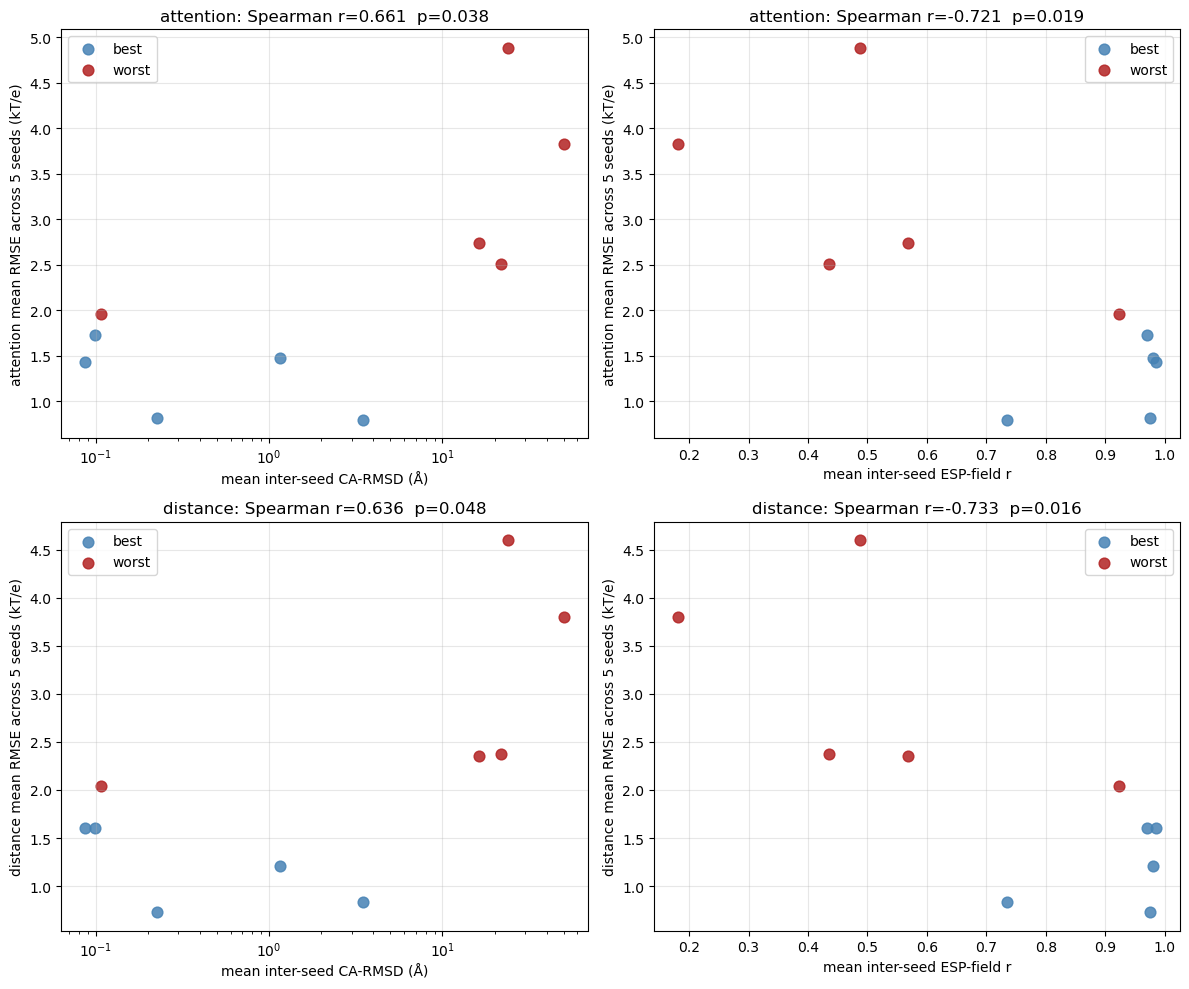

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for col_idx, (agreement_col, agreement_label) in enumerate([
    ("mean_ca_rmsd", "mean inter-seed CA-RMSD (\u00c5)"),
    ("mean_esp_field_r", "mean inter-seed ESP-field r"),
]):
    for row_idx, model in enumerate(["attention", "distance"]):
        ax = axes[row_idx, col_idx]
        target = f"{model}_rmse_mean"
        for group, color in GROUP_COLORS.items():
            sub = agreement[agreement.pilot_group == group]
            ax.scatter(sub[agreement_col], sub[target], color=color, s=60, alpha=0.85, label=group)
        r = spearmanr(agreement[agreement_col], agreement[target])
        ax.set_xlabel(agreement_label)
        ax.set_ylabel(f"{model} mean RMSE across 5 seeds (kT/e)")
        ax.set_title(f"{model}: Spearman r={r.correlation:.3f}  p={r.pvalue:.3f}")
        if agreement_col == "mean_ca_rmsd":
            ax.set_xscale("log")
        ax.legend()
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Per-Seed Error Consistency

Beyond the mean, does a protein with high inter-seed disagreement also show more
*variable* model error across its own 5 seeds (i.e. is the model's accuracy itself
unstable when the input structure is unstable)?

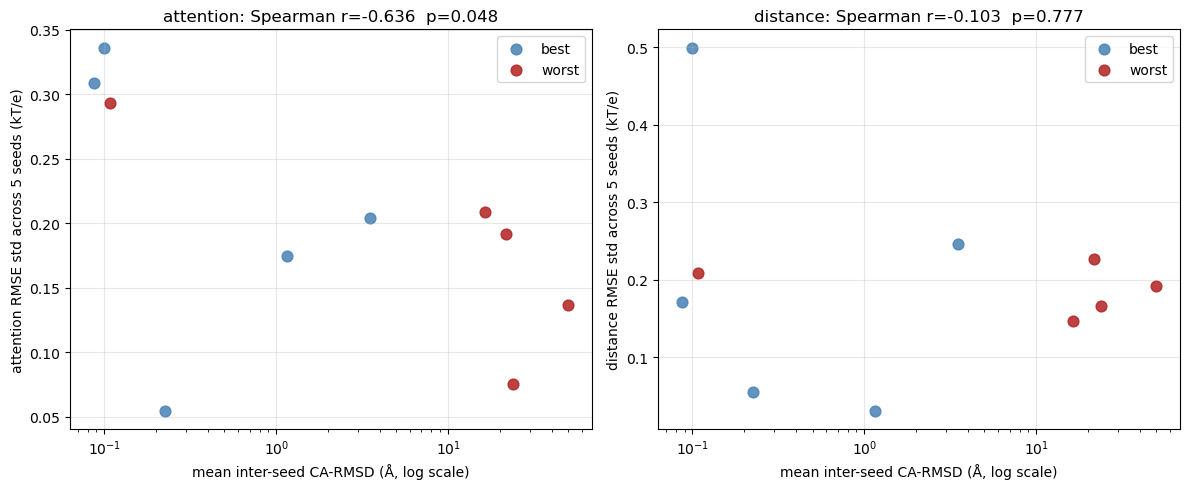

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model in zip(axes, ["attention", "distance"]):
    for group, color in GROUP_COLORS.items():
        sub = agreement[agreement.pilot_group == group]
        ax.scatter(sub["mean_ca_rmsd"], sub[f"{model}_rmse_std"], color=color, s=60, alpha=0.85, label=group)
    r = spearmanr(agreement["mean_ca_rmsd"], agreement[f"{model}_rmse_std"])
    ax.set_xscale("log")
    ax.set_xlabel("mean inter-seed CA-RMSD (\u00c5, log scale)")
    ax.set_ylabel(f"{model} RMSE std across 5 seeds (kT/e)")
    ax.set_title(f"{model}: Spearman r={r.correlation:.3f}  p={r.pvalue:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Notes & Findings

**Headline result: AlphaFold's own inter-seed structural disagreement tracks almost perfectly with which proteins the ESP models get wrong.**

| | best group (mean) | worst group (mean) | Mann-Whitney p |
|---|---|---|---|
| Inter-seed CA-RMSD | 1.01 Å | 22.4 Å | 0.056 |
| Inter-seed ESP-field r | 0.930 | 0.519 | **0.016** |

That's a >20x gap in structural agreement between the two groups, and it isn't just a between-group average artifact — pooling all 10 proteins together (ignoring the best/worst labels entirely), inter-seed disagreement correlates with actual model error at a significance level that's striking for n=10:

| | attention RMSE | distance RMSE |
|---|---|---|
| vs. mean CA-RMSD | r=0.661, p=0.038 | r=0.636, p=0.048 |
| vs. mean ESP-field r | r=−0.721, p=0.019 | r=−0.733, p=0.016 |

**What this means**: for several of the "worst" proteins, AlphaFold doesn't just predict a slightly-different structure across random seeds — it predicts *qualitatively different folds* (CA-RMSD 16–60 Å is far beyond what a converged, high-confidence prediction would show; AF-Q6DGN6-2-F1's seeds disagree so much that two of its four seed-pairs have *negative* cross-seed ESP-field correlation, i.e. the fields are actively anti-correlated, not just noisy). If AlphaFold itself doesn't know what the true structure is, the ESP ground truth computed from any single one of those structures is itself somewhat arbitrary — so part of what looks like "the GNN is bad at this protein" may really be "the structural input this protein's ESP was computed from wasn't a well-defined target to begin with." This is a genuinely different explanation than the dominant one from `error_clustering_analysis.ipynb` (protein size) — it doesn't compete with the size finding so much as offer a second, independent lens on the same hard proteins.

**One important nuance — the model isn't *more erratic* on unstable proteins, just uniformly worse.** Section 4 tested whether high inter-seed structural disagreement also inflates the *variance* of model error across a protein's own 5 seeds (i.e., does an unstable input structure make the model's accuracy itself unpredictable, seed to seed). It doesn't: attention's RMSE-std actually correlates *negatively* with CA-RMSD (r=−0.636, p=0.048 — the opposite of the naive expectation), and distance shows no relationship at all (r=−0.103, p=0.777). Every protein's per-seed RMSE-std stays small (0.03–0.50) relative to its mean RMSE (0.7–4.9) regardless of how much the underlying structures disagree. So the honest reading is: **hard proteins are consistently hard, not erratically hard** — whatever conformation ColabFold happens to produce for a "worst" protein, the model's error stays elevated at roughly the same level, rather than swinging unpredictably between good and bad depending on which seed landed.

**Caveat worth stating plainly**: n=10 is a pilot, not a dataset — these p-values are real but should be read as "worth a full-scale follow-up," not as a settled result. The worst group is also capped at ≤550 residues by this environment's ColabFold limitation (documented at the top of this notebook), so it under-represents the largest, hardest proteins in the true test-set tail; if size and structural instability are correlated (plausible — larger proteins have more conformational degrees of freedom), the true effect at full scale could be stronger or could partially collapse into the already-known size effect. A larger pilot, or one that includes genuinely large proteins (via an external ColabFold run per the earlier decision to accept the local length cap), would be the natural next step to disentangle "large" from "structurally uncertain."
